In [1]:
!pip install anndata==0.8.0

In [13]:
dlx_list = ['Slc32a1', 'Gad1', 'Gad2', 'Grik3', 'Nrxn3', 'Ecel1', 'Actr5', 'Cpne2','Gpc4', 'Eif1b']

In [14]:
nfix_list = ['Chd7','Adamtsl3','Gpd1','Cd9','Htr3a','P2rx7','Rnf141','Fdxr','Abcb8','Lama4']

In [56]:
uncx_list = ['Tmem163','Slc17a6','Cacna2d1','Nrn1','Mab21l2','Chst8','Tmem229b','F13a1','Fras1','Epb41l4a']

In [ ]:
pgr_list = ['Prlr','Svop','Smarcc2','Sin3b','Gpd1l','Crim1','Gria1','Cdh4','Cadps2','Crmp1']

In [2]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [3]:
scenic = pd.read_csv('../../eRegulon_direct_guang.tsv', delimiter = '\t')

In [22]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [9]:
with open('../../parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)
for item in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique():
    if item[:2] == 'mo' or item[:2] == 'mg':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
        
for item in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        print(item)
        parent_dict[item] = 'not hypo'
        
for item in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
        
for item in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
        
for item in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'

327 Oligo NN
326 OPC NN
339 Astrocyte-like NN
341 Macrophage NN
321 Astroependymal NN
329 ABC NN
323 Ependymal NN
322 Tanycyte NN
330 VLMC NN
325 CHOR NN
340 Vascular NN


In [10]:
parent_dict['hypo'] = 'hypo'
parent_dict['not hypo'] = 'not hypo'

In [13]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [2]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.spatial import distance
import os
import scipy
from tqdm import tqdm

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
sam_mg = SAM()
sam_mg.load_data('../../Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i

In [3]:
sam_mo = SAM()
sam_mo.load_data('../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_03122025.h5ad')
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i

In [4]:
sam_cj = SAM()
sam_cj.load_data('../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [5]:
sam_ac= SAM()
sam_ac.load_data('../../Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad')
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i

In [6]:
sam_xt = SAM()
sam_xt.load_data('../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad')
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i

In [7]:
sam_dr = SAM()
sam_dr.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i

In [8]:
TF = pd.read_csv('../../Fin_TF_06012026.csv')
TF_set = set(TF['0'])

In [13]:
otohomo = pd.read_csv('../../OTO_star_nothreshold_6species_ohnlogs_expressionthresh_07232026.tsv',delimiter = '\t', index_col = 'MM')

In [14]:
orthogroups = pd.read_csv('../../Vert_emapper_allorgs_07032026.tsv', delimiter = '\t',index_col = 'Unnamed: 0')
mm_mapping_ortho = orthogroup_mapper(orthogroups, 'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups, 'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups, 'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups, 'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups, 'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [15]:
overall_TF_set = set(otohomo.index) & TF_set

In [142]:
test_genes = ['Pgr', 'Ar']

In [143]:
a = 0
for item in test_genes:
    if item in overall_TF_set:
        a += 1

In [144]:
a

2

In [145]:
exp = sam_mg.adata.X.A
all_exp_ct = np.zeros((sam_mg.adata.obs['subclass_id_label'].nunique(),len(sam_mg.adata.var_names)))
ctl = sam_mg.adata.obs['subclass_id_label'].unique()
for i in range(len(ctl)):
    all_exp_ct[i,:] = np.average(exp[sam_mg.adata.obs['subclass_id_label'] == ctl[i],:], axis = 0)

In [146]:
inv_gene_dict_mg = {v: k for k, v in gene_dict_mg.items()}

In [147]:
fin_genes = []
fin_genes_corr_mg = []
g1_exp_ct = all_exp_ct[:,gene_dict_mg[test_genes[0]]].reshape(-1)
g2_exp_ct = all_exp_ct[:,gene_dict_mg[test_genes[1]]].reshape(-1)
for i in tqdm(range(len(sam_mg.adata.var_names))):
    gene_exp = all_exp_ct[:,i].reshape(-1)
    if np.sum(gene_exp) > 0: 
        if len(set(scenic[scenic['Gene'] == inv_gene_dict_mg[i]]['TF'])& set(test_genes)) > 0 and inv_gene_dict_mg[i] not in TF_set and inv_gene_dict_mg[i] in otohomo.index:
            corr_g1 = stats.pearsonr(gene_exp, g1_exp_ct)[0]
            corr_g2 = stats.pearsonr(gene_exp, g2_exp_ct)[0]
            if np.average([corr_g1,corr_g2]) > .3:
                if (scenic[(scenic['Gene'] == inv_gene_dict_mg[i]) & (scenic['TF'] == test_genes[0])]['regulation'] == 1).all() or (scenic[(scenic['Gene'] == inv_gene_dict_mg[i]) & (scenic['TF'] == test_genes[1])]['regulation'] == 1).all():
                    fin_genes.append(inv_gene_dict_mg[i])
                    fin_genes_corr_mg.append(np.max([corr_g1,corr_g2]))

100%|████████████████████████████████████| 32285/32285 [04:22<00:00, 123.03it/s]


In [148]:
df_corr = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'], index = fin_genes)

In [149]:
df_corr.loc[:,'mm'] = fin_genes_corr_mg

In [150]:
df_corr

,mm,mo,cj,ac,xt,dr
A830018L16Rik,0.498665,NaN,NaN,NaN,NaN,NaN
Zfp451,0.325263,NaN,NaN,NaN,NaN,NaN
Lonrf2,0.468791,NaN,NaN,NaN,NaN,NaN
Fam117b,0.401294,NaN,NaN,NaN,NaN,NaN
Nyap2,0.417379,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
Wdr7,0.543704,NaN,NaN,NaN,NaN,NaN
Cd99l2,0.460478,NaN,NaN,NaN,NaN,NaN
Nhsl2,0.468824,NaN,NaN,NaN,NaN,NaN
Cstf2,0.517207,NaN,NaN,NaN,NaN,NaN


In [151]:
mo_tgenes = otohomo.loc[test_genes,'MO']
cj_tgenes = otohomo.loc[test_genes,'CJ']
ac_tgenes = otohomo.loc[test_genes,'AC']
xt_tgenes = otohomo.loc[test_genes,'XT']
dr_tgenes = otohomo.loc[test_genes,'DR']

In [152]:
mo_fgenes = otohomo.loc[fin_genes,'MO']
cj_fgenes = otohomo.loc[fin_genes,'CJ']
ac_fgenes = otohomo.loc[fin_genes,'AC']
xt_fgenes = otohomo.loc[fin_genes,'XT']
dr_fgenes = otohomo.loc[fin_genes,'DR']

In [153]:
dr_tgenes

MM
Pgr    pgr
Ar      ar
Name: DR, dtype: object

In [154]:
cj_fgenes

MM
A830018L16Rik    C8orf34
Zfp451            ZNF451
Lonrf2            LONRF2
Fam117b          FAM117B
Nyap2              NYAP2
                  ...   
Wdr7                WDR7
Cd99l2            CD99L2
Nhsl2              NHSL2
Cstf2              CSTF2
Tmem35a          TMEM35A
Name: CJ, Length: 107, dtype: object

In [155]:
hypo_ct_mo = [i for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [156]:
exp_mo = sam_mo.adata.X.A
exp_mini_ct_mo = np.zeros((len(hypo_ct_mo),len(sam_mo.adata.var_names)))
for i in range(len(hypo_ct_mo)):
    exp_mini_ct_mo[i,:] = np.average(exp_mo[sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'] == hypo_ct_mo[i],:], axis = 0)
corr_mo = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(mo_tgenes)):
    for j in range(len(mo_fgenes)):
        if mo_fgenes[j] == np.nan:
            corr_mo[j,i] = np.nan
        elif mo_fgenes[j] not in gene_dict_mo.keys():
            corr_mo[j,i] = np.nan
        else:
            corr_mo[j,i] = stats.pearsonr(exp_mini_ct_mo[:,gene_dict_mo[mo_tgenes[i]]], exp_mini_ct_mo[:,gene_dict_mo[mo_fgenes[j]]])[0]

In [157]:
df_corr.loc[:,'mo'] = list(np.amax(corr_mo, axis = 1))

In [158]:
exp_cj = sam_cj.adata.X.A
hypo_ct_cj = [i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_cj = np.zeros((len(hypo_ct_cj),len(sam_cj.adata.var_names)))
for i in range(len(hypo_ct_cj)):
    exp_mini_ct_cj[i,:] = np.average(exp_cj[sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == hypo_ct_cj[i],:], axis = 0)
corr_cj = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(cj_tgenes)):
    for j in range(len(cj_fgenes)):
        if cj_fgenes[j] == np.nan:
            corr_cj[j,i] = np.nan
        elif cj_fgenes[j] not in gene_dict_cj.keys():
            corr_cj[j,i] = np.nan
        else:
            corr_cj[j,i] = stats.pearsonr(exp_mini_ct_cj[:,gene_dict_cj[cj_tgenes[i]]], exp_mini_ct_cj[:,gene_dict_cj[cj_fgenes[j]]])[0]

In [159]:
df_corr.loc[:,'cj'] = list(np.amax(corr_cj, axis = 1))

In [160]:
exp_ac = sam_ac.adata.X.A
hypo_ct_ac = [i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_ac = np.zeros((len(hypo_ct_ac),len(sam_ac.adata.var_names)))
for i in range(len(hypo_ct_ac)):
    exp_mini_ct_ac[i,:] = np.average(exp_ac[sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == hypo_ct_ac[i],:], axis = 0)
corr_ac = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(ac_tgenes)):
    for j in range(len(ac_fgenes)):
        if ac_fgenes[j] == np.nan:
            corr_ac[j,i] = np.nan
        elif ac_fgenes[j] not in gene_dict_ac.keys():
            corr_ac[j,i] = np.nan
        else:
            corr_ac[j,i] = stats.pearsonr(exp_mini_ct_ac[:,gene_dict_ac[ac_tgenes[i]]], exp_mini_ct_ac[:,gene_dict_ac[ac_fgenes[j]]])[0]

In [161]:
df_corr.loc[:,'ac'] = list(np.amax(corr_ac, axis = 1))

In [162]:
exp_xt = sam_xt.adata.X.A
hypo_ct_xt = [i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_xt = np.zeros((len(hypo_ct_xt),len(sam_xt.adata.var_names)))
for i in range(len(hypo_ct_xt)):
    exp_mini_ct_xt[i,:] = np.average(exp_xt[sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == hypo_ct_xt[i],:], axis = 0)
corr_xt = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(xt_tgenes)):
    for j in range(len(xt_fgenes)):
        if xt_fgenes[j] == np.nan:
            corr_xt[j,i] = np.nan
        elif xt_fgenes[j] not in gene_dict_xt.keys():
            corr_xt[j,i] = np.nan
        else:
            corr_xt[j,i] = stats.pearsonr(exp_mini_ct_xt[:,gene_dict_xt[xt_tgenes[i]]], exp_mini_ct_xt[:,gene_dict_xt[xt_fgenes[j]]])[0]

In [163]:
df_corr.loc[:,'xt'] = list(np.amax(corr_xt, axis = 1))

In [164]:
exp_dr = sam_dr.adata.X.A
hypo_ct_dr = [i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_dr = np.zeros((len(hypo_ct_dr),len(sam_dr.adata.var_names)))
for i in range(len(hypo_ct_dr)):
    exp_mini_ct_dr[i,:] = np.average(exp_dr[sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == hypo_ct_dr[i],:], axis = 0)
corr_dr = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(dr_tgenes)):
    for j in range(len(dr_fgenes)):
        if dr_fgenes[j] == np.nan:
            corr_dr[j,i] = np.nan
        elif dr_fgenes[j] not in gene_dict_dr.keys():
            corr_dr[j,i] = np.nan
        else:
            corr_dr[j,i] = stats.pearsonr(exp_mini_ct_dr[:,gene_dict_dr[dr_tgenes[i]]], exp_mini_ct_dr[:,gene_dict_dr[dr_fgenes[j]]])[0]

In [165]:
df_corr.loc[:,'dr'] = list(np.amax(corr_dr, axis = 1))

In [166]:
df_corr

,mm,mo,cj,ac,xt,dr
A830018L16Rik,0.498665,-0.093947,0.190386,0.224603,0.125252,-0.072307
Zfp451,0.325263,0.096731,-0.029414,0.003581,0.241218,0.150903
Lonrf2,0.468791,0.618082,0.023209,-0.092788,0.347521,0.277636
Fam117b,0.401294,0.243064,0.121532,0.236300,0.237933,0.120527
Nyap2,0.417379,0.060978,-0.061226,-0.132564,0.296097,0.474062
...,...,...,...,...,...,...
Wdr7,0.543704,0.320754,0.074040,0.022807,0.326444,0.027633
Cd99l2,0.460478,0.052511,0.044663,0.082750,0.404397,0.252545
Nhsl2,0.468824,0.263788,0.148767,0.223481,-0.083847,0.282623
Cstf2,0.517207,0.073921,0.158119,-0.152077,0.235531,0.198042


In [167]:
df_corr = df_corr.loc[df_corr['mm'].sort_values(ascending = False).index,:]
df_corr_lim = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'])
a = 0
while len(df_corr_lim.index) < 10:
    if df_corr.loc[df_corr.index[a],:].isna().sum() <= 1:
        df_corr_lim.loc[df_corr.index[a],:] = df_corr.loc[df_corr.index[a],:]
    a+= 1

In [168]:
df_corr_lim

,mm,mo,cj,ac,xt,dr
Prlr,0.671924,0.618628,0.250404,0.171409,0.343158,-0.047623
Crmp1,0.62806,0.157286,-0.036226,0.010737,0.073701,0.253635
Svop,0.6008,0.286252,0.162253,0.048772,0.324722,0.256944
Cadps2,0.590202,0.279997,-0.044379,0.171049,-0.009282,0.138972
Cdh4,0.586641,0.355646,0.051525,0.338394,0.115722,0.199804
Crim1,0.58265,0.185982,0.206567,0.246627,0.187142,0.45423
Gpd1l,0.57962,0.171819,-0.007852,0.003885,0.222225,0.482638
Sin3b,0.576882,0.19154,0.103515,0.035061,0.22955,0.456132
Gria1,0.569924,0.189242,0.17839,0.170623,0.188108,0.267187
Smarcc2,0.562809,0.379376,0.011136,-0.134905,0.3363,0.472418


In [169]:
df_corr_lim = df_corr_lim.astype('float')

In [181]:
order = ['Prlr','Svop','Smarcc2','Sin3b','Gpd1l','Crim1','Gria1','Cdh4','Cadps2','Crmp1']

In [182]:
set(df_corr_lim.index) == set(order)

True

In [183]:
set(df_corr_lim.index) - set(order)

set()

In [184]:
set(order) - set(df_corr_lim.index)

set()

In [185]:
print(len(set(order)))

10


In [186]:
df_corr_order = df_corr_lim.loc[order,:]

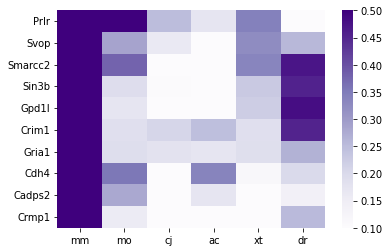

In [188]:
ax = sns.heatmap(df_corr_order, cmap = 'Purples', vmax = .5, vmin = 0.1)
ax.set_facecolor('grey')
plt.savefig('../../Figures/Figures_07242026/3F_Pgr_Ar_downstream_scenic_noTF_07232026.svg')
plt.savefig('../../Figures/Figures_07242026/3F_Pgr_Ar_downstream_scenic_noTF_07232026.pdf')

In [189]:
df_corr_order

,mm,mo,cj,ac,xt,dr
Prlr,0.671924,0.618628,0.250404,0.171409,0.343158,-0.047623
Svop,0.600800,0.286252,0.162253,0.048772,0.324722,0.256944
Smarcc2,0.562809,0.379376,0.011136,-0.134905,0.336300,0.472418
Sin3b,0.576882,0.191540,0.103515,0.035061,0.229550,0.456132
Gpd1l,0.579620,0.171819,-0.007852,0.003885,0.222225,0.482638
Crim1,0.582650,0.185982,0.206567,0.246627,0.187142,0.454230
Gria1,0.569924,0.189242,0.178390,0.170623,0.188108,0.267187
Cdh4,0.586641,0.355646,0.051525,0.338394,0.115722,0.199804
Cadps2,0.590202,0.279997,-0.044379,0.171049,-0.009282,0.138972
Crmp1,0.628060,0.157286,-0.036226,0.010737,0.073701,0.253635


In [190]:
df_corr_order.to_csv('../../Figures/Figures_07242026/3F_Pgr_Ar_downstream_scenic_noTF_07232026.csv')

In [ ]:
#checking regulation

In [152]:
df_corr_order = pd.read_csv('Figures/Figures_07072026/3F_Dlx_Isl1_downstream_scenic_noTF_07072026.csv',index_col = 'Unnamed: 0')

In [154]:
df_corr_order.index

Index(['Slc32a1', 'Gad1', 'Gad2', 'Grik3', 'Nrxn3', 'Ecel1', 'Actr5', 'Cpne2',
       'Gpc4', 'Eif1b'],
      dtype='object')

In [103]:
g_mapping = pd.DataFrame(data = [dlx_list,
                     [mo_exp[i] for i in dlx_list],
                     [cj_exp[i] for i in dlx_list],
                     [ac_exp[i] for i in dlx_list],
                     [xt_exp[i] for i in dlx_list],
                     [dr_exp[i] for i in dlx_list]],
             index = ['Mouse name','Vole name','Quail name','Anole name','Xenopus name','Zebrafish name']).T

In [104]:
g_mapping

,Mouse name,Vole name,Quail name,Anole name,Xenopus name,Zebrafish name
0,Slc32a1,Slc32a1,SLC32A1,slc32a1,slc32a1,slc32a1
1,Gad1,Gad1,GAD1,gad1,gad1.1,gad1b
2,Gad2,Gad2,GAD2,gad2,gad2,gad2
3,Grik3,Grik3,GRIK3,grik3,grik3,grik3
4,Nrxn3,Nrxn3,NRXN3,nrxn3,nrxn3,nrxn3a
5,Ecel1,Ecel1,ECEL1,ecel1,ecel1,ecel1
6,Actr5,Actr5,ACTR5,actr5,actr5,actr5
7,Abat,Abat,ABAT,abat,NaN,abat
8,Gpc4,Gpc4,GPC4,gpc4,gpc4,gpc4
9,Eif1b,ENSMOCG00000000649,EIF1B,eif1b,eif1b,eif1b


In [240]:
neb = ['Tmem163','Slc17a6','Dpf3','Nrn1','Adora1','Cxxc5','Chst8','Samd3','Cacna2d1','F13a1','Fras1','Mrps15','Epb41l4a','Ly75','Tmem229b']
ntcf = ['St18','Nfia','Nfib','Zfp536','Chd7','Adamtsl3','Mcm6','S100a16','P2rx7','Dennd2a','Rnf141','Htr3a','Fdxr','Gpd1','Tns3']

In [239]:
for item in neb:
    TFs = set(scenic[scenic['Gene'] == item]['TF'])
    print(item)
    if 'Ebf3' in TFs:
        print('Ebf3')
    if 'Uncx' in TFs:
        print('Uncx')

Tmem163
Uncx
Slc17a6
Uncx
Dpf3
Uncx
Nrn1
Uncx
Adora1
Ebf3
Cxxc5
Uncx
Chst8
Uncx
Samd3
Uncx
Cacna2d1
Uncx
F13a1
Uncx
Fras1
Uncx
Mrps15
Uncx
Epb41l4a
Uncx
Ly75
Uncx
Tmem229b
Uncx


In [243]:
for item in ntcf:
    TFs = set(scenic[scenic['Gene'] == item]['TF'])
    print(item)
    if 'Tcf4' in TFs:
        print('Tcf4')
    if 'Nfix' in TFs:
        print('Nfix')
    print('----')

St18
Nfix
----
Nfia
Tcf4
Nfix
----
Nfib
Tcf4
Nfix
----
Zfp536
Nfix
----
Chd7
Tcf4
Nfix
----
Adamtsl3
Tcf4
----
Mcm6
Tcf4
----
S100a16
Nfix
----
P2rx7
Tcf4
----
Dennd2a
Tcf4
Nfix
----
Rnf141
Nfix
----
Htr3a
Nfix
----
Fdxr
Tcf4
Nfix
----
Gpd1
Nfix
----
Tns3
Tcf4
Nfix
----
